In [2]:
dataPath = "data/LMUK-RADONC-PHYS-RES__DoseRAD2026/proton/training"
sample = "1ABB011"

# Image loading

In [1]:
import numpy as np
import json
import SimpleITK as sitk
import pandas as pd
import torch
from monai.transforms import (
    Compose,
    LoadImaged,
    EnsureChannelFirstd,
    Spacingd,
    ResizeWithPadOrCropd,
    EnsureTyped,
    ScaleIntensityRanged,  # optional but useful for HU clipping
)
from monai.visualize import plot_2d_or_3d_image, matshow3d
from monai.transforms import LoadImaged

In [ ]:


TARGET_SPACING = (2.0, 2.0, 3.0)
TARGET_SIZE    = (256, 256, 64)


In [15]:

transforms = Compose([
    LoadImaged(keys=["HU"], image_only=False),
    EnsureChannelFirstd(keys=["HU"]),
    Spacingd(
        keys=["HU"],
        pixdim=TARGET_SPACING,
        mode="trilinear",     
        align_corners=True,
    ),
    ResizeWithPadOrCropd(
        keys=["HU"],
        spatial_size=TARGET_SIZE,
        mode="constant",
        constant_values=-1000,  # HU air value, better than 0 for CT
    ),
    EnsureTyped(keys=["HU"], dtype=torch.float32),
])


In [8]:
sample_dict = {"HU": f"{dataPath}/{sample}/image/ct.mha"}
data = transforms(sample_dict)


In [18]:
img,metadata = data["HU"], data["HU_meta_dict"]

# Visualizations

In [27]:
img.shape

torch.Size([1, 256, 256, 64])

(<Figure size 1000x1000 with 1 Axes>,
 array([[   nan,    nan,    nan, ...,    nan,    nan,    nan],
        [   nan, -1000., -1000., ..., -1000., -1000.,    nan],
        [   nan, -1000., -1000., ..., -1000., -1000.,    nan],
        ...,
        [   nan, -1000., -1000., ..., -1000., -1000.,    nan],
        [   nan, -1000., -1000., ..., -1000., -1000.,    nan],
        [   nan,    nan,    nan, ...,    nan,    nan,    nan]],
       dtype=float32))

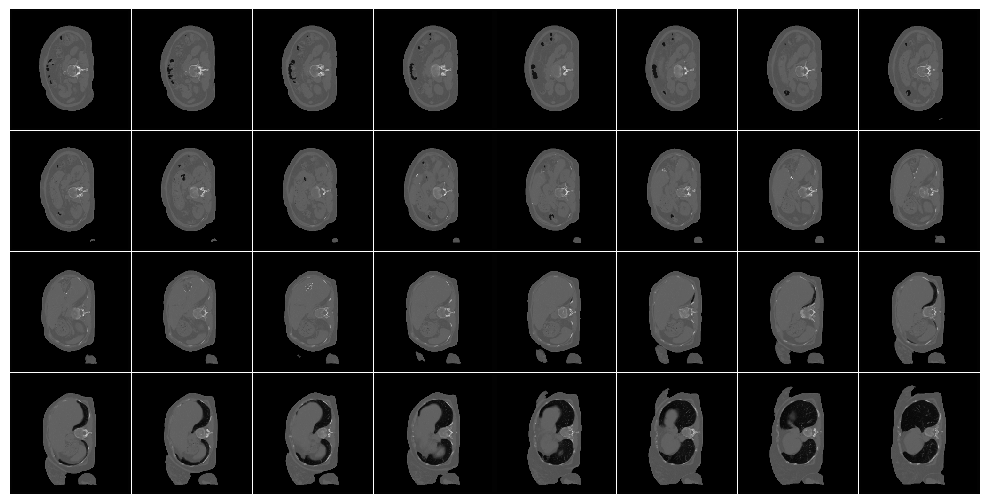

In [33]:
matshow3d(img,every_n = 2, frames_per_row = 8,cmap ="gray",frame_dim = -1)

# Data exploration

Todo: Find out what would be the optimal spacing distribution. 

In [3]:
import json

In [4]:
beam_parameters = json.load(open(f"{dataPath}/beam_parameters.json"))

In [7]:
beam_parameters["hu_to_density"]

{'_note': 'HU-to-density calibration curve used by G4DCM. 10 anchor points linearly interpolated. Both photon and proton simulations use identical tables.',
 'entries': [{'hu': -1024, 'density_g_cm3': 0.0012},
  {'hu': -999, 'density_g_cm3': 0.00121},
  {'hu': -200, 'density_g_cm3': 0.8043754},
  {'hu': -199, 'density_g_cm3': 0.8183035},
  {'hu': -10, 'density_g_cm3': 1.006579},
  {'hu': -9, 'density_g_cm3': 0.9966749},
  {'hu': 120, 'density_g_cm3': 1.126553},
  {'hu': 121, 'density_g_cm3': 1.095097},
  {'hu': 3000, 'density_g_cm3': 3.027294},
  {'hu': 4000, 'density_g_cm3': 3.698428}]}

In [8]:
sample_metadata = json.load(open(f"{dataPath}/{sample}/{sample}.json"))

In [12]:
sample_metadata.keys()

dict_keys(['iso_center', 'beams'])

In [11]:
sample_metadata["iso_center"]

[-108.0453, -4.5438, -18.3033]

In [13]:
sample_metadata['beams']

[{'beam_idx': 0,
  'gantry_angle': 0.0,
  'rays': [{'ray_idx': 0,
    'ray_source': [-108.05, -1004.54, -58.3],
    'ray_target': [-108.05, -4.539999999999964, -58.3],
    'beamlets': [{'beamlet_idx': 0, 'energy': 167.4618},
     {'beamlet_idx': 1, 'energy': 148.7208}]},
   {'ray_idx': 1,
    'ray_source': [-138.05, -1004.54, -58.3],
    'ray_target': [-138.05, -4.539999999999964, -58.3],
    'beamlets': [{'beamlet_idx': 0, 'energy': 150.3508},
     {'beamlet_idx': 1, 'energy': 200.7966}]},
   {'ray_idx': 2,
    'ray_source': [-113.05, -1004.54, -58.3],
    'ray_target': [-113.05, -4.539999999999964, -58.3],
    'beamlets': [{'beamlet_idx': 0, 'energy': 199.4943},
     {'beamlet_idx': 1, 'energy': 92.9319}]},
   {'ray_idx': 3,
    'ray_source': [-108.05, -1004.54, -38.3],
    'ray_target': [-108.05, -4.539999999999964, -38.3],
    'beamlets': [{'beamlet_idx': 0, 'energy': 171.8982},
     {'beamlet_idx': 1, 'energy': 49.5354}]},
   {'ray_idx': 4,
    'ray_source': [-138.05, -1004.54, -3

In [21]:
sample_metadata['beams'][0]['rays'][0]

{'ray_idx': 0,
 'ray_source': [-108.05, -1004.54, -58.3],
 'ray_target': [-108.05, -4.539999999999964, -58.3],
 'beamlets': [{'beamlet_idx': 0, 'energy': 167.4618},
  {'beamlet_idx': 1, 'energy': 148.7208}]}

In [ ]:
print("Beam Index:", sample_metadata['beams'][0]['beam_idx'])
print("Ray Index:", sample_metadata['beams'][0]['rays'][0]['ray_idx'])


Beam Index: 0
Ray Index: 0


In [28]:
sample_input = sample_metadata['beams'][0]['rays'][0]['ray_source'], sample_metadata['beams'][0]['rays'][0]['beamlets'][0]['energy']